# Multi-Class Sentiment Analyzer with Error Analysis

### Task 17 – NLP Assignment

This notebook builds a **three-class sentiment classifier**:

- **Negative**
- **Neutral**
- **Positive**

It follows the mentor's required NLP pipeline:

**Dataset → Data Understanding → Text Cleaning → Train/Test Split → TF-IDF → Machine Learning Model → Evaluation → Confusion Matrix → Error Analysis → New Predictions**

### Improvement over the basic mentor version

The assignment suggests Logistic Regression. To improve performance on high-dimensional sparse TF-IDF text features, this notebook uses **Linear Support Vector Machine (`LinearSVC`)** as the main classifier. Linear SVM is a strong traditional NLP classifier for large text datasets and works efficiently with sparse TF-IDF matrices.

The notebook also:
- uses **unigrams + bigrams**
- uses **sublinear TF-IDF scaling**
- removes duplicate/empty records
- preserves negation words such as `not`, `no`, and `never`
- evaluates using **accuracy, precision, recall and F1-score**
- performs **8-category error analysis**
- compares actual vs predicted labels
- shows the most common confusion pairs
- provides a reusable prediction function


## 1. Libraries

The assignment specifies pandas, numpy, matplotlib and scikit-learn. Additional standard-library modules are used only for text cleaning and file handling.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
LABEL_MAP = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

The supplied CSV contains these columns:

- `Unnamed: 0` – index column
- `Comment` – text
- `Sentiment` – numeric sentiment label

For the assignment, we convert these into the required `text` and `sentiment` columns.

Expected label mapping used by the supplied dataset:

- `0` → Negative
- `1` → Neutral
- `2` → Positive


In [2]:
# Locate sentiment_data.csv in the notebook folder or nearby folders
DATA_FILE = Path("sentiment_data.csv")

if not DATA_FILE.exists():
    candidates = list(Path(".").rglob("sentiment_data.csv"))
    if candidates:
        DATA_FILE = candidates[0]

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "sentiment_data.csv was not found. Put the CSV in the same folder as this notebook."
    )

print("Using dataset:", DATA_FILE.resolve())

try:
    raw_df = pd.read_csv(DATA_FILE)
except pd.errors.EmptyDataError:
    raise ValueError("The CSV file is empty.")
except Exception as e:
    raise RuntimeError(f"Could not read the CSV file: {e}")

print("Dataset loaded successfully.")
print("Shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())


Using dataset: C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 17 - Multi-Class Sentiment Analyzer with Error Analysis Using Basic NLP\S.GayathriG40-AIML\sentiment_data.csv
Dataset loaded successfully.
Shape: (241145, 3)
Columns: ['Unnamed: 0', 'Comment', 'Sentiment']


## 3. Understand the Dataset

In [3]:
display(raw_df.head())

print("\nDataset information:")
raw_df.info()

print("\nMissing values:")
print(raw_df.isnull().sum())

print("\nDuplicate rows:", raw_df.duplicated().sum())


,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  241145 non-null  int64
 1   Comment     240928 non-null  str  
 2   Sentiment   241145 non-null  int64
dtypes: int64(2), str(1)
memory usage: 5.5 MB

Missing values:
Unnamed: 0      0
Comment       217
Sentiment       0
dtype: int64

Duplicate rows: 0


In [4]:
# Validate the expected columns
required_columns = {"Comment", "Sentiment"}
missing_columns = required_columns - set(raw_df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Keep only the columns required for the assignment
df = raw_df[["Comment", "Sentiment"]].copy()

# Rename to assignment-friendly names
df = df.rename(columns={
    "Comment": "text",
    "Sentiment": "sentiment"
})

# Convert numeric labels to readable sentiment names
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")
df = df.dropna(subset=["text", "sentiment"]).copy()

df["sentiment"] = df["sentiment"].astype(int)

invalid_labels = sorted(set(df["sentiment"]) - set(LABEL_MAP))
if invalid_labels:
    raise ValueError(f"Unexpected sentiment labels found: {invalid_labels}")

df["sentiment"] = df["sentiment"].map(LABEL_MAP)

# Clean raw text spacing and remove empty records
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0].copy()

# Remove duplicate text-label pairs
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)

print("Final usable dataset shape:", df.shape)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())


Final usable dataset shape: (214333, 2)

Sentiment distribution:
sentiment
positive    94251
neutral     71771
negative    48311
Name: count, dtype: int64


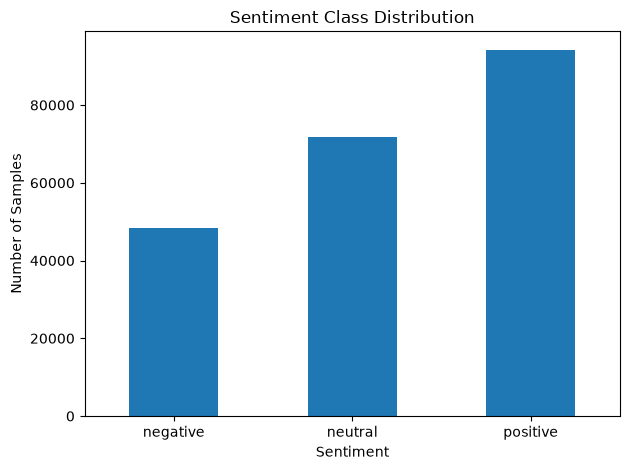

Class proportions:
sentiment
negative    22.54%
neutral     33.49%
positive    43.97%
Name: count, dtype: str


In [5]:
# Visualize class distribution
class_counts = df["sentiment"].value_counts().reindex(
    ["negative", "neutral", "positive"]
)

class_counts.plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Class proportions:")
print((class_counts / len(df) * 100).round(2).astype(str) + "%")


## 4. Text Preprocessing

The basic assignment recommends:
- lowercase conversion
- URL removal
- special-character cleanup
- whitespace normalization

For sentiment analysis, this notebook **does not remove negation words** such as `not`, `no`, and `never`, because they are important for meaning.

Examples:
- `not good`
- `never enjoyed`
- `no improvement`

Bigrams in TF-IDF will allow the model to learn useful patterns such as these.

In [6]:
def clean_text(text):
    """Basic, sentiment-friendly text cleaning."""
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Normalize common apostrophe forms
    text = text.replace("’", "'").replace("‘", "'")

    # Keep letters, spaces and apostrophes; remove noisy symbols/digits
    text = re.sub(r"[^a-z\s']", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

# Remove rows that became empty after cleaning
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

display(df[["text", "clean_text", "sentiment"]].head(10))
print("Rows after text cleaning:", len(df))


,text,clean_text,sentiment
0,lets forget apple pay required brand new iphon...,lets forget apple pay required brand new iphon...,neutral
1,nz retailers don’t even contactless credit car...,nz retailers don't even contactless credit car...,negative
2,forever acknowledge channel help lessons ideas...,forever acknowledge channel help lessons ideas...,positive
3,whenever go place doesn’t take apple pay doesn...,whenever go place doesn't take apple pay doesn...,negative
4,apple pay convenient secure easy use used kore...,apple pay convenient secure easy use used kore...,positive
5,we’ve hounding bank adopt apple pay understand...,we've hounding bank adopt apple pay understand...,neutral
6,got apple pay south africa it’s widely accepted,got apple pay south africa it's widely accepted,positive
7,need apple pay physical credit card,need apple pay physical credit card,neutral
8,united states abundance retailers accept apple...,united states abundance retailers accept apple...,positive
9,cambodia universal qr code system scan send mo...,cambodia universal qr code system scan send mo...,neutral


Rows after text cleaning: 214067


## 5. Define Input and Target

- `X` = cleaned text
- `y` = sentiment class

In [7]:
X = df["clean_text"]
y = df["sentiment"]

print("Number of samples:", len(X))
print("Classes:", sorted(y.unique()))


Number of samples: 214067
Classes: ['negative', 'neutral', 'positive']


## 6. Train-Test Split

We use an **80/20 stratified split** with `random_state=42`.

`stratify=y` keeps the class proportions approximately equal in training and testing data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training samples: 171253
Testing samples: 42814

Training distribution:
sentiment
negative    0.226
neutral     0.334
positive    0.440
Name: proportion, dtype: float64

Testing distribution:
sentiment
negative    0.226
neutral     0.334
positive    0.440
Name: proportion, dtype: float64


## 7. TF-IDF Feature Extraction

TF-IDF converts text into numerical features.

### Improvements used here

- `ngram_range=(1, 2)` → learns unigrams and bigrams
- `sublinear_tf=True` → reduces the effect of extremely frequent terms
- `min_df=2` → ignores one-off vocabulary noise
- `max_df=0.95` → ignores terms appearing in almost every document
- `max_features=30000` → controls memory usage while keeping a rich vocabulary

The vectorizer is **fit only on training data** to prevent test-data leakage.

In [9]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))


Training TF-IDF shape: (171253, 30000)
Testing TF-IDF shape: (42814, 30000)
Vocabulary size: 30000


## 8. Train the Improved Model – Linear SVM

### Algorithm: Linear Support Vector Machine (`LinearSVC`)

For large text classification problems, Linear SVM is a strong traditional machine-learning choice because:
- TF-IDF produces high-dimensional sparse features.
- Linear SVM is designed to work efficiently with such feature spaces.
- It often performs very well on text classification.
- It does not require dense conversion of the TF-IDF matrix.

`C=2.0` provides a slightly stronger fit than the default value while retaining regularization.

In [10]:
model = LinearSVC(
    C=2.0,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model.fit(X_train_tfidf, y_train)

print("Linear SVM training completed.")


Linear SVM training completed.


## 9. Make Predictions

In [11]:
y_pred = model.predict(X_test_tfidf)

print("First 20 predictions:")
print(y_pred[:20])


First 20 predictions:
['positive' 'positive' 'positive' 'positive' 'neutral' 'positive'
 'neutral' 'neutral' 'positive' 'negative' 'negative' 'negative'
 'positive' 'neutral' 'neutral' 'neutral' 'negative' 'neutral' 'negative'
 'negative']


## 10. Model Evaluation

We evaluate the model using the metrics required by the assignment:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Because this is a multi-class problem, **macro F1-score** is especially useful because it gives equal importance to all three sentiment classes.

In [12]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy     : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Macro F1     : {macro_f1:.4f}")
print(f"Weighted F1  : {weighted_f1:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        labels=["negative", "neutral", "positive"],
        digits=4
    )
)


Accuracy     : 0.7811 (78.11%)
Macro F1     : 0.7710
Weighted F1  : 0.7817

Classification Report:

              precision    recall  f1-score   support

    negative     0.7217    0.7190    0.7204      9660
     neutral     0.7400    0.8065    0.7718     14311
    positive     0.8500    0.7935    0.8208     18843

    accuracy                         0.7811     42814
   macro avg     0.7705    0.7730    0.7710     42814
weighted avg     0.7843    0.7811    0.7817     42814



### Important

Do **not** write a fixed accuracy such as 82% in the report. Use the actual value printed by this notebook after execution.

## 11. Confusion Matrix

The diagonal contains correct predictions. Off-diagonal cells show which sentiment classes are being confused.

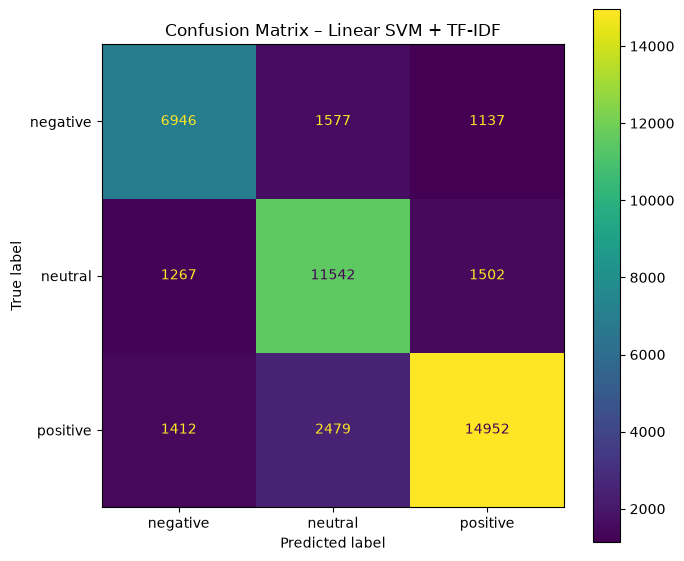

Confusion matrix:


,negative,neutral,positive
negative,6946,1577,1137
neutral,1267,11542,1502
positive,1412,2479,14952


In [13]:
labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix – Linear SVM + TF-IDF")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
display(pd.DataFrame(cm, index=labels, columns=labels))


# 12. Error Analysis

Error analysis examines **why** incorrect predictions happen instead of looking only at accuracy.

The mentor's assignment identifies five major error types:
1. Negation
2. Mixed sentiment
3. Neutral sentiment
4. Sarcasm
5. Rare words

This notebook expands the analysis to **8 error categories**:

6. Context-dependent sentence  
7. Short sentence  
8. Slang / noisy spelling / social-media style

The categories are detected using transparent keyword/heuristic rules. They are **diagnostic labels**, not proof of the true linguistic cause. Therefore, examples should also be manually reviewed.

In [14]:
# Build a results table containing both original and cleaned text
results = pd.DataFrame({
    "text": X_test.index.map(df.loc[X_test.index, "text"]),
    "clean_text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
}).reset_index(drop=True)

errors = results[results["actual"] != results["predicted"]].copy()

print("Total test samples:", len(results))
print("Incorrect predictions:", len(errors))
print(f"Error rate: {len(errors) / len(results) * 100:.2f}%")

display(errors.head(20))


Total test samples: 42814
Incorrect predictions: 9374
Error rate: 21.89%


,text,clean_text,actual,predicted
6,managed find places combine fun pleasure savin...,managed find places combine fun pleasure savin...,positive,neutral
9,modis claims bogus one never heard rigmarole l...,modis claims bogus one never heard rigmarole l...,positive,negative
13,jobs donâ give farmers donâ talk women atr...,jobs don give farmers don talk women atrocitie...,positive,neutral
15,join april small meets family friends relative...,join april small meets family friends relative...,negative,neutral
16,iaf crashing left right still modi wanna play,iaf crashing left right still modi wanna play,positive,negative
21,upa govt years rule never talked jobs vanish l...,upa govt years rule never talked jobs vanish l...,positive,neutral
32,capability lacked political always missing ing...,capability lacked political always missing ing...,negative,neutral
34,fact remember ever lyric like came yesterday s...,fact remember ever lyric like came yesterday s...,positive,neutral
35,secular anti hindu mulla modi also pro dalit b...,secular anti hindu mulla modi also pro dalit b...,positive,neutral
37,saw game huge cavs fan lol pay refs yaos rest ...,saw game huge cavs fan lol pay refs yaos rest ...,neutral,positive


In [15]:
# Count the most common actual -> predicted confusions
confusion_pairs = (
    errors.groupby(["actual", "predicted"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

print("Most common error pairs:")
display(confusion_pairs)


Most common error pairs:


,actual,predicted,count
0,positive,neutral,2479
1,negative,neutral,1577
2,neutral,positive,1502
3,positive,negative,1412
4,neutral,negative,1267
5,negative,positive,1137


## 13. Define the 8 Error Types

### 1. Negation
Examples: `not good`, `never liked`, `no improvement`

### 2. Mixed Sentiment
Positive and negative cues occur in the same sentence.

### 3. Neutral Sentiment
Weak/ambiguous words such as `okay`, `average`, `fine`, `normal`, `ordinary`.

### 4. Sarcasm
Sarcastic patterns often contain positive words but express a negative opinion.

### 5. Rare Vocabulary
Important words that occur very infrequently in the training data.

### 6. Context-Dependent
The meaning depends heavily on context, reference, or surrounding information.

### 7. Short Sentence
Very short text contains limited information.

### 8. Slang / Noisy Spelling
Internet abbreviations, repeated letters, informal spelling, or social-media noise.

In [16]:
# Build training vocabulary statistics for rare-word analysis
train_tokens = X_train.str.split().explode()
train_token_counts = train_tokens.value_counts()

negation_words = {"not", "no", "never", "neither", "nor", "hardly", "without", "isn't", "wasn't", "don't", "didn't", "can't", "won't"}

positive_words = {
    "amazing", "awesome", "excellent", "great", "good", "love", "loved",
    "wonderful", "fantastic", "best", "perfect", "enjoy", "enjoyed",
    "happy", "brilliant", "outstanding", "nice"
}

negative_words = {
    "bad", "terrible", "awful", "horrible", "hate", "hated", "boring",
    "worst", "poor", "disappointed", "disappointing", "waste", "worst",
    "sad", "angry", "annoying", "useless"
}

neutral_words = {
    "okay", "ok", "average", "fine", "normal", "ordinary", "moderate",
    "decent", "nothing", "usual", "standard", "acceptable"
}

sarcasm_markers = {
    "yeah right", "sure", "great", "wow", "thanks", "brilliant",
    "what a", "love that"
}

context_markers = {
    "this", "that", "it", "they", "he", "she", "them", "there",
    "again", "as usual", "you know"
}

slang_patterns = [
    r"\b lol \b", r"\b lmao \b", r"\b omg \b", r"\b idk \b",
    r"\b btw \b", r"\b imo \b", r"\b tbh \b", r"\b pls \b",
    r"\b u \b", r"\b ur \b", r"\b rn \b", r"\b thx \b"
]

def contains_any_phrase(text, phrases):
    text = f" {text.lower()} "
    return any(f" {p} " in text for p in phrases)

def classify_error_type(text):
    t = text.lower().strip()
    tokens = t.split()

    # Priority is intentional: a sentence can satisfy multiple patterns,
    # but we assign one primary diagnostic category.
    if any(word in tokens for word in negation_words):
        return "1. Negation"

    pos_hits = sum(word in tokens for word in positive_words)
    neg_hits = sum(word in tokens for word in negative_words)
    if pos_hits > 0 and neg_hits > 0:
        return "2. Mixed sentiment"

    if any(word in tokens for word in neutral_words):
        return "3. Neutral sentiment"

    if contains_any_phrase(t, sarcasm_markers) and (
        neg_hits > 0 or "another" in tokens or "again" in tokens
    ):
        return "4. Sarcasm"

    if len(tokens) <= 4:
        return "7. Short sentence"

    # Rare vocabulary: important token is seen only once in training
    rare_tokens = [
        tok for tok in tokens
        if tok.isalpha() and train_token_counts.get(tok, 0) <= 1
    ]
    if rare_tokens:
        return "5. Rare vocabulary"

    # Context-dependent references
    if any(tok in context_markers for tok in tokens) and len(tokens) <= 8:
        return "6. Context-dependent"

    # Social-media slang / noisy spelling
    if any(re.search(pattern, f" {t} ") for pattern in slang_patterns):
        return "8. Slang/noisy spelling"

    # Repeated characters such as "goooood", "baaad"
    if re.search(r"(.)\1{2,}", t):
        return "8. Slang/noisy spelling"

    return "Uncategorized"

errors["error_type"] = errors["clean_text"].apply(classify_error_type)

print("Error-type distribution:")
display(
    errors["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)


Error-type distribution:


,error_type,count
0,Uncategorized,4183
1,5. Rare vocabulary,3290
2,7. Short sentence,823
3,1. Negation,493
4,3. Neutral sentiment,317
5,8. Slang/noisy spelling,134
6,2. Mixed sentiment,115
7,4. Sarcasm,18
8,6. Context-dependent,1


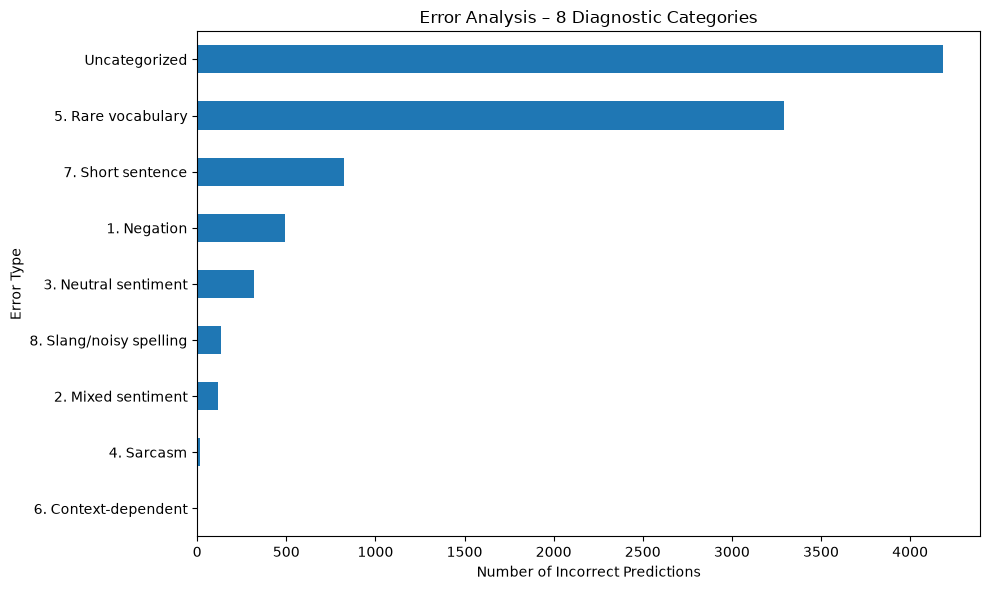

In [17]:
# Visualize the 8 error categories
error_type_counts = errors["error_type"].value_counts()

plt.figure(figsize=(10, 6))
error_type_counts.sort_values().plot(kind="barh")
plt.title("Error Analysis – 8 Diagnostic Categories")
plt.xlabel("Number of Incorrect Predictions")
plt.ylabel("Error Type")
plt.tight_layout()
plt.show()


## 14. Inspect Examples for Each Error Type

This table helps connect the quantitative error counts with real examples.

In [18]:
for error_type in sorted(errors["error_type"].unique()):
    subset = errors[errors["error_type"] == error_type][
        ["text", "actual", "predicted"]
    ].head(5)

    print("\n" + "=" * 80)
    print(error_type)
    print("=" * 80)
    display(subset)



1. Negation


,text,actual,predicted
9,modis claims bogus one never heard rigmarole l...,positive,negative
15,join april small meets family friends relative...,negative,neutral
21,upa govt years rule never talked jobs vanish l...,positive,neutral
147,dhume one thing keep mind modi never even invo...,negative,positive
247,day console actually provides compromise won’t...,neutral,positive



2. Mixed sentiment


,text,actual,predicted
525,pretty good app take notes lists smart snooze ...,neutral,positive
956,bad cant come enjoy urself tho,neutral,negative
1091,think wud matter great pride prime minister wo...,neutral,negative
1226,machines produce everything need outcome depen...,neutral,positive
1338,good experience nice concept sad completely fr...,neutral,negative



3. Neutral sentiment


...

,text,actual,predicted
85,wheres love,neutral,positive
90,im workbored mind,negative,neutral
141,twittering days,neutral,negative
168,widget feezing every night,negative,neutral
244,time get purrtty wink,positive,neutral



8. Slang/noisy spelling


,text,actual,predicted
97,one criticised isro criticising chowkidaar mod...,positive,neutral
349,sold hit cash took tax tips drawer ended dolla...,negative,neutral
483,ten hag mastermind way positions maguire inspi...,neutral,positive
1023,ughhh think plans ruined excited,neutral,positive
1029,sooo much better biology scores bad,neutral,negative



Uncategorized


,text,actual,predicted
6,managed find places combine fun pleasure savin...,positive,neutral
16,iaf crashing left right still modi wanna play,positive,negative
32,capability lacked political always missing ing...,negative,neutral
34,fact remember ever lyric like came yesterday s...,positive,neutral
35,secular anti hindu mulla modi also pro dalit b...,positive,neutral


## 15. Most Difficult Sentiment Class

A class with the lowest recall or F1-score is a useful target for further improvement.

In [19]:
report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    output_dict=True
)

class_metrics = pd.DataFrame(report).T.loc[
    labels, ["precision", "recall", "f1-score", "support"]
]

display(class_metrics)

hardest_class = class_metrics["f1-score"].idxmin()
print(f"Lowest F1-score class: {hardest_class}")


,precision,recall,f1-score,support
negative,0.721662,0.719048,0.720353,9660.0
neutral,0.739967,0.806512,0.771808,14311.0
positive,0.849980,0.793504,0.820772,18843.0


Lowest F1-score class: negative


## 16. Inspect Errors by Actual Sentiment

Neutral examples are often harder in basic sentiment models, but this notebook determines the actual hardest class from the measured F1-score instead of assuming it.

In [20]:
for label in labels:
    class_errors = errors[errors["actual"] == label]
    print(f"{label.title()} actual examples incorrectly classified: {len(class_errors)}")
    if len(class_errors):
        display(class_errors[["text", "actual", "predicted"]].head(5))


Negative actual examples incorrectly classified: 2714


,text,actual,predicted
15,join april small meets family friends relative...,negative,neutral
32,capability lacked political always missing ing...,negative,neutral
39,narendra modi says prime ministers visit aalo ...,negative,positive
66,whole lot people support one reason right dadr...,negative,positive
90,im workbored mind,negative,neutral


Neutral actual examples incorrectly classified: 2769


,text,actual,predicted
37,saw game huge cavs fan lol pay refs yaos rest ...,neutral,positive
50,photos described app made seem like whitelist ...,neutral,negative
70,question happens done naturally generated wate...,neutral,positive
85,wheres love,neutral,positive
127,either deshdrohi pakistani ever opposed irresp...,neutral,negative


Positive actual examples incorrectly classified: 3891


,text,actual,predicted
6,managed find places combine fun pleasure savin...,positive,neutral
9,modis claims bogus one never heard rigmarole l...,positive,negative
13,jobs donâ give farmers donâ talk women atr...,positive,neutral
16,iaf crashing left right still modi wanna play,positive,negative
21,upa govt years rule never talked jobs vanish l...,positive,neutral


## 17. Prediction Function for New Text

In [21]:
def predict_sentiment(sentence):
    """Predict sentiment for one new sentence."""
    if not isinstance(sentence, str) or not sentence.strip():
        raise ValueError("Please provide a non-empty sentence.")

    cleaned = clean_text(sentence)
    if not cleaned:
        raise ValueError("The sentence became empty after cleaning.")

    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)[0]
    return prediction

examples = [
    "This product is absolutely amazing and I love it",
    "The product arrived yesterday and works as expected",
    "This is a terrible and disappointing experience",
    "The movie was not bad at all"
]

for sentence in examples:
    print(f"{sentence} -> {predict_sentiment(sentence)}")


This product is absolutely amazing and I love it -> positive
The product arrived yesterday and works as expected -> neutral
This is a terrible and disappointing experience -> negative
The movie was not bad at all -> neutral


## 18. Batch Prediction

You can replace the examples below with your own sentences.

In [22]:
test_sentences = [
    "I really enjoyed this movie",
    "The movie was average",
    "I hated this movie",
    "The service was excellent",
    "Nothing special happened",
    "This was a complete waste of money"
]

prediction_table = pd.DataFrame({
    "text": test_sentences,
    "predicted_sentiment": [predict_sentiment(s) for s in test_sentences]
})

display(prediction_table)


,text,predicted_sentiment
0,I really enjoyed this movie,positive
1,The movie was average,neutral
2,I hated this movie,negative
3,The service was excellent,positive
4,Nothing special happened,positive
5,This was a complete waste of money,negative


# 19. Final Results Summary

This cell creates a compact result table that can be copied into the project report or README after running the notebook.

In [23]:
summary = pd.DataFrame({
    "Metric": [
        "Dataset samples",
        "Training samples",
        "Testing samples",
        "TF-IDF features",
        "Model",
        "Accuracy",
        "Macro F1",
        "Weighted F1",
        "Incorrect predictions",
        "Error rate"
    ],
    "Value": [
        len(df),
        len(X_train),
        len(X_test),
        X_train_tfidf.shape[1],
        "TF-IDF + LinearSVC",
        f"{accuracy:.4f}",
        f"{macro_f1:.4f}",
        f"{weighted_f1:.4f}",
        len(errors),
        f"{len(errors) / len(results) * 100:.2f}%"
    ]
})

display(summary)


,Metric,Value
0,Dataset samples,214067
1,Training samples,171253
2,Testing samples,42814
3,TF-IDF features,30000
4,Model,TF-IDF + LinearSVC
5,Accuracy,0.7811
6,Macro F1,0.7710
7,Weighted F1,0.7817
8,Incorrect predictions,9374
9,Error rate,21.89%


# 20. Error Analysis Findings

After running the notebook, use the measured error table and examples to write findings. The eight categories investigated are:

1. **Negation** – the model may struggle when words such as `not`, `never`, or `no` reverse the sentiment of a nearby word.
2. **Mixed sentiment** – positive and negative opinions in the same sentence can create conflicting TF-IDF signals.
3. **Neutral sentiment** – neutral language often contains fewer strong sentiment words.
4. **Sarcasm** – the literal words can express the opposite of the intended meaning.
5. **Rare vocabulary** – uncommon words may have limited representation in training.
6. **Context-dependent sentences** – short references such as `it`, `that`, or `again` can require information outside the sentence.
7. **Short sentences** – fewer words provide fewer useful features.
8. **Slang/noisy spelling** – informal spelling and internet abbreviations can create vocabulary variation.

### Important reporting rule

Only claim an error category as a major finding if the notebook's **error counts and inspected examples support it**. The heuristic labels are intended to guide manual review, not replace it.


# 21. Model Choice and Improvements

### Why Linear SVM?

The original assignment demonstrates Logistic Regression. This notebook uses **LinearSVC** as the main model because it is a strong classical algorithm for sparse, high-dimensional text features.

### Improvements used

- Larger real-world dataset
- Duplicate and empty-text removal
- Sentiment-friendly preprocessing
- Negation preservation
- TF-IDF unigrams + bigrams
- Sublinear TF scaling
- Minimum/maximum document-frequency filtering
- 30,000 feature limit for a practical memory footprint
- Stratified 80/20 split
- Class-balanced Linear SVM
- Macro F1 evaluation
- Eight-category error analysis

### Possible future improvements

For a more advanced project, the next step could be comparing:
- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM

or moving to contextual models such as BERT/DistilBERT. Those would go beyond the assignment's **basic NLP** scope, so they are not used here.


# 22. Methodology

```text
Dataset
   ↓
Data Validation
   ↓
Remove Missing / Empty / Duplicate Records
   ↓
Text Cleaning
   ↓
80/20 Stratified Train-Test Split
   ↓
TF-IDF (Unigrams + Bigrams)
   ↓
Linear SVM (LinearSVC)
   ↓
Sentiment Prediction
   ↓
Accuracy / Precision / Recall / F1
   ↓
Confusion Matrix
   ↓
Incorrect Prediction Extraction
   ↓
8-Category Error Analysis
   ↓
New Sentence Prediction
```


# 23. Conclusion

This project implements a complete **multi-class sentiment analysis pipeline** using basic NLP and machine learning.

The model predicts:
- Positive
- Neutral
- Negative

The main NLP representation is **TF-IDF**, while the final classifier is **Linear SVM (`LinearSVC`)**. The model is evaluated using accuracy, precision, recall, F1-score and a confusion matrix.

The project also performs detailed error analysis using eight diagnostic categories:
**negation, mixed sentiment, neutral sentiment, sarcasm, rare vocabulary, context dependence, short sentences, and slang/noisy spelling**.

The final accuracy and error patterns must be taken from the actual notebook output after execution.


# 24. Viva Preparation

### Q1. What is sentiment analysis?
It is an NLP task that identifies the opinion or emotional polarity expressed in text.

### Q2. Why is this a multi-class problem?
Because the model predicts three possible classes: positive, neutral and negative.

### Q3. What is TF-IDF?
TF-IDF converts text into numerical features based on term importance within documents and across the corpus.

### Q4. Why use bigrams?
Bigrams capture two-word patterns such as `not good`, `very bad`, and `really enjoyed`, which can carry more meaning than individual words.

### Q5. Why use LinearSVC?
Linear SVM is effective for high-dimensional sparse text features and is a strong traditional classifier for NLP.

### Q6. Why use `fit_transform()` only on training data?
To prevent information from the test set leaking into model training.

### Q7. Why use `stratify=y`?
It maintains approximately the same class proportions in training and testing data.

### Q8. What is a confusion matrix?
It shows how many examples from each actual class were predicted as each class.

### Q9. What is error analysis?
It is the examination of incorrect predictions to understand model weaknesses and identify ways to improve the system.

### Q10. Why can sarcasm be difficult?
A basic TF-IDF model mostly uses word patterns and does not deeply understand contextual or implied meaning.
